Some exercises for the problem solving session

Problem from group assignment 1: what is the expected number of coin tosses before the first head appears? Let's say we have computed it and want to check if it is reasonable: use simulation!

In [1]:
import numpy as np



In [2]:
n = 100000
# store a sequence of required attempts in n trials
all_req_attempts = np.array([])
for i in range(n):
  # required attempts in a current run
  req_attempts = 0
  
  while(1):
    head_or_coin = np.random.choice(2, 1)
    req_attempts = req_attempts + 1
    if(head_or_coin == 1):
      # when we finally got a head, remember the number of attempts
        all_req_attempts = np.append(all_req_attempts, req_attempts)
        break


all_req_attempts.mean()

np.float64(2.00543)

Chapter 1, problem 5

## Problem 5, Chap 1

In [3]:
import numpy as np

In [4]:
# the function returns True if we have obtained 2 heads, say head = 1 and tail = 0
def true_event(sequence):
    # check first if the sequence has 2 heads:
    if (np.sum(sequence) == 2):
        # if yes, check if the last element of the sequence was 1 - then the sequence is correct
        if (sequence[-1] == 1):
            return 1
    # otherwise, we got our number wrong
    return 0

In [26]:
k = 4
# randint (a, b) generates random numbers in [a, b) ! so b is not included
# generate a sequence of outcomes of size k = 4
x = np.random.randint(0,2,size=k)

print(x)
true_event(x)

[1 1 0 0]


0

Now define a function that takes a vector of sequences and for each returns true or false

In [35]:
def true_event_vector(sequence):
    return (np.sum(x,axis=1) == 2)*(x[:,-1] == 1)

In [41]:
k_max = 4

x = np.random.randint(0,2,size=(100_000,k))
x

array([[1, 1, 0, 1],
       [0, 0, 0, 0],
       [1, 1, 1, 1],
       ...,
       [1, 0, 1, 0],
       [1, 0, 1, 0],
       [0, 1, 0, 1]], shape=(100000, 4), dtype=int32)

Empirically compute the probability (the fraction of 1s in the obtained sequence)

In [50]:
np.mean(true_event_vector(x))

np.float64(0.1863)

What is the actual probability that k trials required? Hint: what is the probability of obtaining exactly 1 head in k-1 trials?

negative binomial formula 

In [52]:
p = 1/2
(k-1)*((1-p)**(k-2)*p)*p

0.1875

## Problem 10, Chap 1

In [53]:
import numpy as np

In [68]:
# the door can take values 1, 2, 3
door = np.random.randint(1,4,size=100000)

print(door)
#print(door)
# we pick the 1st door 
np.mean(door == 1) # Probability of getting a price when not switching

[3 3 1 ... 3 2 1]


np.float64(0.33352)

Now let's compute the probability of changing to another door

In [69]:
from random import randint
host = [] # Door opened by host
for d in door:
    if (d == 1):
        # Randomly open either 2 or 3
        host.append(randint(2,3))
    elif (d == 2):
        host.append(3)
    elif (d == 3):
        host.append(2)

In [70]:
switch_success = [] # If switching was a success
for d,h in zip(door,host):
    if (h == 2) and d==3: # Switching from 1 to 3 was a success
        switch_success.append(1)
    elif (h == 3) and d==2: # Switching from 1 to 2 was a success
        switch_success.append(1)
    else:
        switch_success.append(0)

In [73]:
np.mean(switch_success)

np.float64(0.66648)

Problem from group assignment 1: What is the CDF and PDF of R = sqrt(X^2 + Y^2) where X and Y are uniformly distributed on a unit disc. Let's simulate the points first

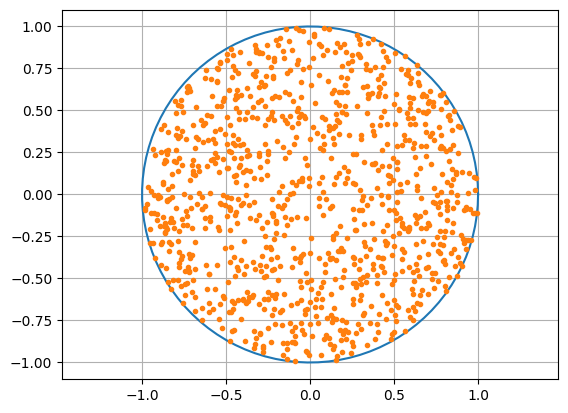

In [81]:
import numpy as np
import matplotlib.pyplot as plt

n = 1000
r = np.random.uniform(low=0, high=1, size=n)  # radius
theta = np.random.uniform(low=0, high=2*np.pi, size=n)  # angle

# Polar coordinates transformation
x = np.sqrt(r) * np.cos(theta)
y = np.sqrt(r) * np.sin(theta)

# make the line
a = np.linspace(0, 2*np.pi, 100)
# perform a transformation to do a circle
cx,cy = np.cos(a), np.sin(a)

fg, ax = plt.subplots(1, 1)
ax.plot(cx, cy,'-') # draw unit circle line
ax.plot(x, y, '.') # plot random points
ax.axis('equal')
ax.grid(True)
fg.canvas.draw()
plt.show()

Now let's look at R:

In [78]:
r = np.sqrt(x**2 + y**2)
r

array([0.74843233, 0.56247269, 0.74302897, 0.37616407, 0.93852277,
       0.97067162, 0.36102626, 0.15930047, 0.95206387, 0.5774846 ,
       0.32495103, 0.93778459, 0.62105883, 0.42419942, 0.6024232 ,
       0.57789925, 0.47396613, 0.20275784, 0.51825079, 0.28714585,
       0.72852439, 0.63872379, 0.10708572, 0.98910729, 0.58619393,
       0.82144285, 0.71473535, 0.79527848, 0.39360769, 0.96271149,
       0.95326207, 0.51768196, 0.30894538, 0.84637047, 0.31345491,
       0.21715041, 0.77224734, 0.46418918, 0.93491529, 0.83480813,
       0.33078829, 0.26258313, 0.59456358, 0.99175445, 0.83225623,
       0.30113048, 0.93865891, 0.20500235, 0.76255723, 0.60613397,
       0.47688138, 0.97884383, 0.93723759, 0.76057072, 0.85569629,
       0.24735284, 0.1917086 , 0.92395658, 0.76303689, 0.27489059,
       0.85788774, 0.74349236, 0.3717831 , 0.55171981, 0.11598364,
       0.6693276 , 0.94286894, 0.86188631, 0.78762803, 0.77196024,
       0.88715994, 0.66816005, 0.61477042, 0.47946922, 0.73350

Check histogram of R

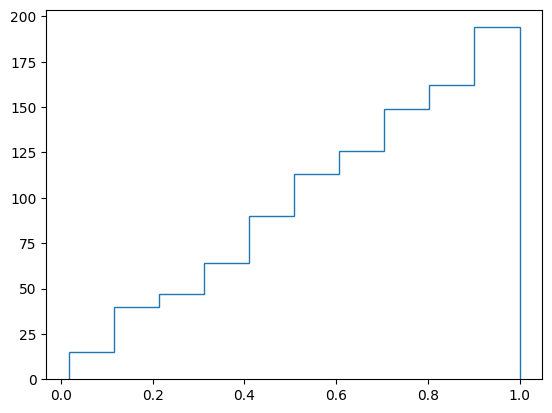

In [79]:
counts, bins = np.histogram(r)
plt.stairs(counts, bins)
plt.show()

Check the PMF and CDF; Use the Utils script to make and plot the empirical distribution

In [86]:
from Utils import makeEDF, plotEDF


c:\Users\mkami\OneDrive\Pulpit\UNI\upp-uni\sem1\intro-data-science\first_lecture_and_data\Utils.py:363: SyntaxWarning: invalid escape sequence '\i'
  Uses the information P(X \in [min_value,max_value]) = 1 and uses Hoeffding to compute


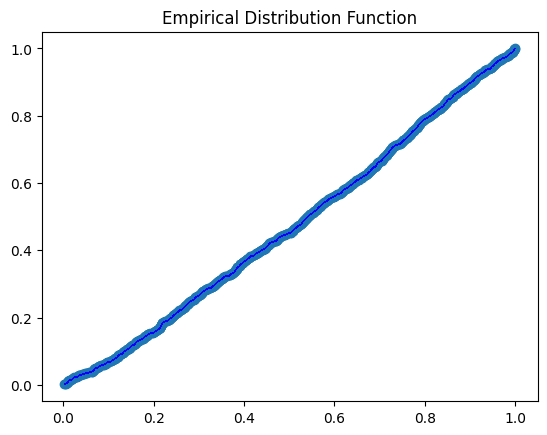

In [87]:
my_edf = makeEDF(r)
my_edf

plotEDF(my_edf)

In [88]:
r.mean()

np.float64(0.5282788813091073)

Some work with text parsing

In [89]:
csv_file = open('breast_cancer.csv', 'r')

# read the whole data line by line
all_lines = csv_file.readlines()

# obtain a list, each element of which is a single line from the imported csv file 

all_lines



FileNotFoundError: [Errno 2] No such file or directory: 'breast_cancer.csv'

In [21]:
all_lines[0]

'id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst\n'

We see that there is a line break in the end, how to get rid of it?

In [22]:
all_lines[0].strip()

'id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst'